# Numerical simulation

$$
\newcommand{\eg}{{\it e.g.}}
\newcommand{\ie}{{\it i.e.}}
\newcommand{\argmin}{\operatornamewithlimits{argmin}}
\newcommand{\mc}{\mathcal}
\newcommand{\mb}{\mathbb}
\newcommand{\mf}{\mathbf}
\newcommand{\minimize}{{\text{minimize}}}
\newcommand{\diag}{{\text{diag}}}
\newcommand{\cond}{{\text{cond}}}
\newcommand{\rank}{{\text{rank }}}
\newcommand{\range}{{\mathcal{R}}}
\newcommand{\null}{{\mathcal{N}}}
\newcommand{\tr}{{\text{trace}}}
\newcommand{\dom}{{\text{dom}}}
\newcommand{\dist}{{\text{dist}}}
\newcommand{\R}{\mathbf{R}}
\newcommand{\SM}{\mathbf{S}}
\newcommand{\ball}{\mathcal{B}}
\newcommand{\bmat}[1]{\begin{bmatrix}#1\end{bmatrix}}
\newcommand{\loss}{\ell}
\newcommand{\eloss}{\mc{L}}
\newcommand{\abs}[1]{| #1 |}
\newcommand{\norm}[1]{\| #1 \|}
\newcommand{\tp}{T}
$$

__<div style="text-align: right"> ASE3001: Computational Experiments for Aerospace Engineering, Inha University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@inha.ac.kr) </div>_
_<div style="text-align: right"> Seungyeop Lee (seungyeoplee@inha.edu) </div>_
_<div style="text-align: right"> Hyejin Park (hyejinPark@inha.edu) </div>_

<br>

---

## Dynamic model

A "system" is defined as an entity that generates an output in response to a given input, and the "state" of the system represents its condition at a specific point in time. The rule that determines how the state changes over time is called as the "dynamics" of the system.

In continuous time, the dynamics are typically described by a differential equation of the form

$$
\dot{x}(t) = f(x(t), u(t), t),
$$

where $u(t)$ denotes the "input" to the system. In a time-invariant system, the function $f$ is independent of time $t$, whereas in a time-varying system, $f$ explicitly depends on $t$ as shown in above example.

"Numerical simulation" is the process of solving this differential equation, given an initial state $x_0$, in order to compute the trajectory of the state over time $t$.

<br>

---

## Numerical Integration

In numerical simulation, in addition to the system dynamics, a crucial component is "integration".
Integration can be performed analytically in some cases, but in "numerical integration", the time domain is discretized into a finite set of points, and the state is updated sequentially over these small time intervals.

Formally, consider a continuous-time system with dynamics

$$
\dot{x}(t) = f(x(t), u(t), t), \quad x(t_0) = x_0.
$$

To perform numerical integration, we discretize time into steps $t_0, t_1, \dots, t_N$ with a uniform step size $\Delta t = t_{k+1} - t_k$, and approximate the state evolution sequentially:

$$
x_{k+1} \approx x_k + \int_{t_k}^{t_{k+1}} f(x(t), u(t), t)\, dt.
$$

Several intuitive and widely used numerical integration methods exist. Among the simplest are "Euler integration" and "trapezoidal integration" (also called the "trapezoidal rule").

* "Euler integration" updates the state as

$$
x_{k+1} = x_k + \Delta t \, f(x_k, u_k, t_k).
$$

* "Trapezoidal integration" improves accuracy by using the average slope over the interval:

$$
x_{k+1} = x_k + \frac{\Delta t}{2} \big( f(x_k, u_k, t_k) + f(x_{k+1}, u_{k+1}, t_{k+1}) \big).
$$

These methods provide simple yet effective approaches to approximate the evolution of continuous-time dynamics in a "discrete-time framework", which is essential for simulation and control design.


<br>

---

## Numerical Simulation Example : Satellite Orbit Propagation

We now illustrate the use of "Euler integration" and "trapezoidal integration" to numerically propagate a satellite’s orbit around Earth for example.

#### 1. Satellite State Definition

The satellite "state vector" is defined as

$$
x =
\begin{bmatrix}
\mathbf{r} \\
\mathbf{v} \\
\mathbf{q} \\
\boldsymbol{\omega}
\end{bmatrix}
\in \mathbb{R}^{13}
$$

where

- $\mathbf{r} = (x, y, z)$ is the position in inertial coordinates (meters),
- $\mathbf{v} = (v_x, v_y, v_z)$ is the velocity (m/s),
- $\mathbf{q} = (q_x, q_y, q_z, q_w)$ is the attitude quaternion,
- $\boldsymbol{\omega} = (\omega_x, \omega_y, \omega_z)$ is the angular velocity (rad/s) in the body frame.

#### 2. Satellite Dynamics

The dynamics of the satellite are given by:

$$
\begin{align*}
\dot{\mathbf{r}} &= \mathbf{v}, \\
\dot{\mathbf{v}} &= - \frac{\mu}{r^3} \mathbf{r}, \\
\dot{\mathbf{q}} &= \frac{1}{2} \mathbf{\Omega}(\boldsymbol{\omega}) \mathbf{q}, \\
\dot{\boldsymbol{\omega}} &= \mathbf{J}^{-1} \left( \mathbf{\tau} - \boldsymbol{\omega} \times (\mathbf{J} \boldsymbol{\omega}) \right),
\end{align*}
$$

where

- $\mu = 3.986\times10^{14}\,\text{m}^3/\text{s}^2$ is Earth’s gravitational parameter,
- $r = \|\mathbf{r}\|$ is the radial distance from Earth’s center,
- $\mathbf{\Omega}(\boldsymbol{\omega})$ is the quaternion kinematics matrix(this will be given in code),
- $\mathbf{J} = \text{diag}(100, 120, 80)\,\text{kg}\cdot\text{m}^2$ is the inertia matrix,
- $\mathbf{\tau} = \mathbf{0}$ (no external torque).

#### 3. Initial State

We set the initial state as:

$$
x_0 =
\begin{bmatrix}
x_0 & y_0 & z_0 &
v_{x0} & v_{y0} & v_{z0} &
q_x & q_y & q_z & q_w &
\omega_x & \omega_y & \omega_z
\end{bmatrix}^T\\
=
\begin{bmatrix}
7000\times10^3& 0& 0 &
0& 7.546& 0 &
0& 0& 0& 1 &
0& 0& 0
\end{bmatrix}^T.
$$

- The satellite is initially at an altitude of 700 km along the x-axis, moving tangentially along the y-axis to maintain a circular orbit.
- No initial rotation is assumed.

<br>

---

_**(Problem 1)**_ Now, implement both "Euler integration" and "trapezoidal integration" to propagate the satellite state from the initial time $t=0$ to the orbital period $T = 2\pi \sqrt{r^3/\mu} \approx 5,832\ \text{s}$.

The satellite’s **initial state** is given as $x_0$, and the state is propagated using different time steps:

$$
\Delta t = \{1\,\text{s}, 10\,\text{s}, 60\,\text{s}\}.
$$

Compute for each integration method, and each time steps. You have to yield these six trajectories:

1. Euler integration with $\Delta t = 1\,\text{s}$
2. Euler integration with $\Delta t = 10\,\text{s}$
3. Euler integration with $\Delta t = 60\,\text{s}$
4. Trapezoidal integration with $\Delta t = 1\,\text{s}$
5. Trapezoidal integration with $\Delta t = 10\,\text{s}$
6. Trapezoidal integration with $\Delta t = 60\,\text{s}$

**Personalized step size (by student ID).** In addition to the six cases above, each student must also run **both** integration methods with an individualized step size

$$
\Delta t_\text{personal} =
\begin{cases}
\frac{d}{10} \ \text{s}, & \text{if } d \in \{1,\dots,9\} \text{ is the last digit of your student ID},\\[2pt]
0.01\ \text{s}, & \text{if the last digit } d=0\,.
\end{cases}
$$

Examples: if your ID ends with 7, use $\Delta t=0.7\,\text{s}$; if it ends with 0, use $\Delta t=0.01\,\text{s}$.

7. Euler integration with $\Delta t = \Delta t_\text{personal}$
8. Trapezoidal integration with $\Delta t = \Delta t_\text{personal}$


In [1]:
import numpy              as np
import numpy.linalg       as nl
import matplotlib.pyplot  as plt

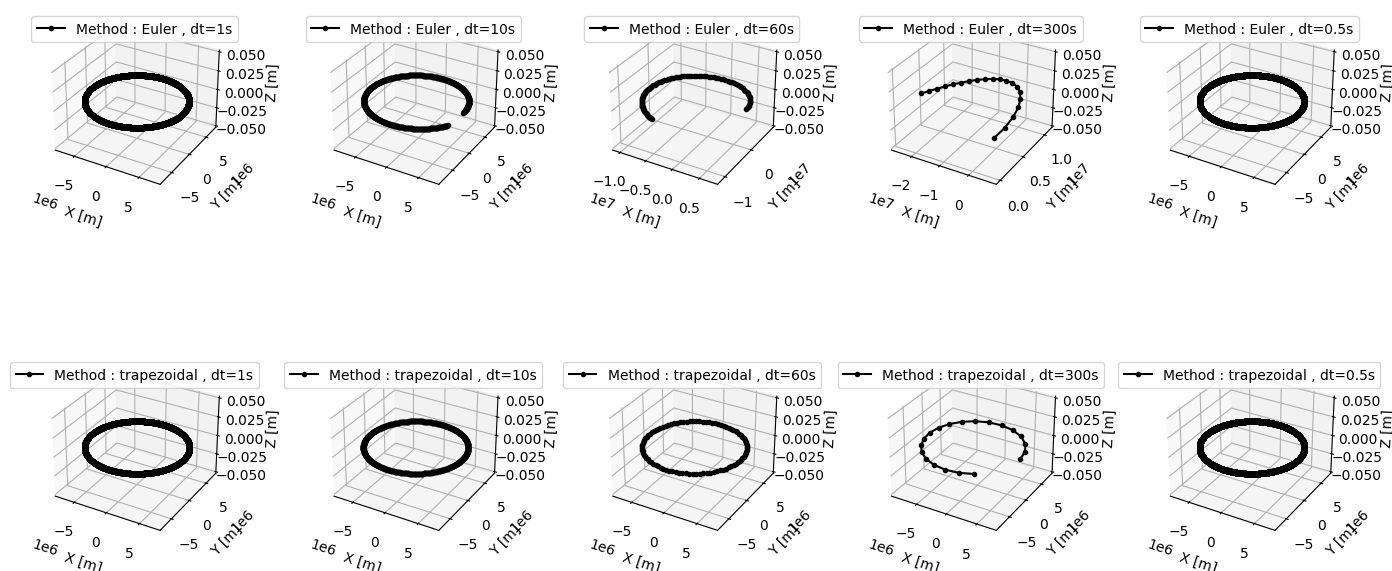

In [2]:
### Parameters                # Descriptions                        # Units
mu = 3.986e14                 # Earth's gravitational parameter     [m^3/s^2]
J  = np.diag([100, 120, 80])  # Satellite inertia matrix            [kg·m²]
T  = 5832                     # Orbital period                      [s]
r0 = 7000e3                   # Initial orbital radius              [m]
v0 = np.sqrt(mu / r0)         # Circular orbit velocity             [m/s]

### Initial state
x0 = np.array([
    r0, 0, 0,       # position
    0, v0, 0,       # velocity
    0, 0, 0, 1,     # quaternion
    0, 0, 0         # angular velocity
])

### Dynamics
# Rotation kinematics
def Omega(w):
    wx, wy, wz = w
    return np.array([
        [0,  -wx, -wy, -wz],
        [wx,   0,  wz, -wy],
        [wy, -wz,   0,  wx],
        [wz,  wy, -wx,   0]
    ])

# Dynamics model f(x)#################
import scipy.integrate as spi

def f(z,t=None):
    r,v,q,w = z[0:3],z[3:6],z[6:10],z[10:13]
    rdot=v
    vdot=-mu/(nl.norm(r)**3)*r
    qdot=0.5*Omega(w)@q
    wdot=np.linalg.inv(J)@(-np.cross(w, J @ w))
    return np.concatenate((rdot,vdot,qdot,wdot))

def euler(x_k,dt):
    x_next=x_k+dt*f(x_k)
    return x_next
def trapezoidal(x_k,dt):
    x_next=euler(x_k,dt)
    x_next=x_k+dt/2*(f(x_k)+f(x_next))
    return x_next

dts=[1,10,60,300,0.5] # From ID, the last digit is 5 .. so dt_personal = 0.5
def process(x0,dt,T):
    steps=int(T/dt)
    x_e,x_t=np.zeros((steps+1,len(x0))),np.zeros((steps+1,len(x0)))
    x_e[0],x_t[0]=x0,x0
    for i in range(steps):
        x_e[i,6:10]/=np.linalg.norm(x_e[i,6:10])
        x_t[i,6:10]/=np.linalg.norm(x_t[i,6:10])
        x_e[i+1]=euler(x_e[i],dt)
        x_t[i+1]=trapezoidal(x_t[i],dt)
    return x_e,x_t

from mpl_toolkits.mplot3d import Axes3D
fig,axes=plt.subplots(2,len(dts),subplot_kw={'projection': '3d'},figsize=(14, 8))
for i in range(2):
    for j, dt in enumerate(dts):
        ax=axes[i,j]
        X_e,X_t=process(x0,dt,T) 
        
        if i == 0:  # Euler
            x,y,z=X_e[:,0],X_e[:,1],X_e[:,2]
            ax.plot(x, y, z, 'k.-', label=f"Method : Euler , dt={dt}s")
        else:   # trapezoidal
            x,y,z=X_t[:,0],X_t[:,1],X_t[:,2]
            ax.plot(x, y, z, 'k.-', label=f"Method : trapezoidal , dt={dt}s")
            
        ax.legend(loc='upper center')
        ax.set_xlabel("X [m]")
        ax.set_ylabel("Y [m]")
        ax.set_zlabel("Z [m]")

plt.tight_layout()
plt.show()
######################################


<br>

---

## Runge–Kutta Integration

As observed in the previous example, as the time step $\Delta t$ increases, both Euler and trapezoidal integration accumulate errors, resulting in inaccurate trajectories.

However, it is not always feasible to reduce $\Delta t$ arbitrarily to improve accuracy, because a smaller $\Delta t$ requires a larger number of time steps, which increases computational cost.

To address this, "Runge–Kutta (RK) integration" can be employed. RK methods provide higher accuracy than the previously introduced integration techniques, allowing relatively small errors even with larger $\Delta t$.

Runge–Kutta methods are classified by their order, such as RK4, RK5, etc., according to the order of accuracy. The most commonly used fourth-order method, RK4, is defined as follows:

$$
\begin{aligned}
k_1 &= f(x_k, t_k), \\
k_2 &= f\Big(x_k + \frac{\Delta t}{2} k_1, t_k + \frac{\Delta t}{2}\Big), \\
k_3 &= f\Big(x_k + \frac{\Delta t}{2} k_2, t_k + \frac{\Delta t}{2}\Big), \\
k_4 &= f(x_k + \Delta t \, k_3, t_k + \Delta t), \\
x_{k+1} &= x_k + \frac{\Delta t}{6} (k_1 + 2 k_2 + 2 k_3 + k_4)
\end{aligned}
$$

This approach achieves fourth-order accuracy, meaning that the local truncation error is proportional to $(\Delta t)^5$, and the global error scales with $(\Delta t)^4$.

<br>

---

_**(Problem 2)**_ Now, let us implement the fourth-order Runge–Kutta (RK4) method introduced above. And repeat the same simulation with the RK4 integrator you implemented

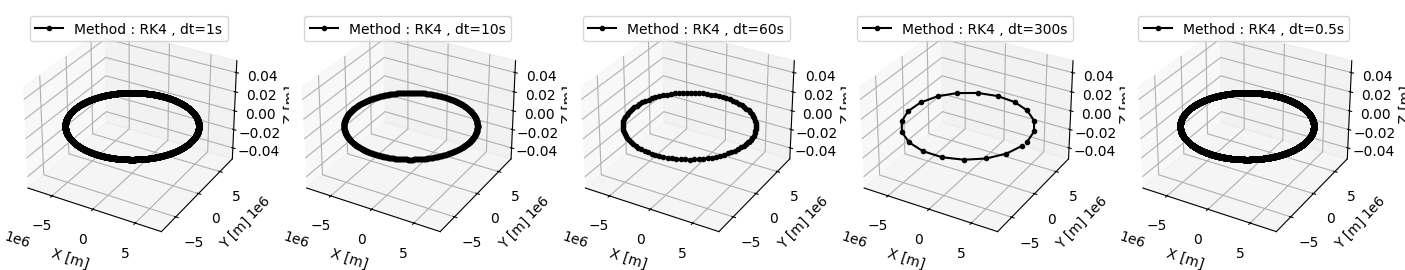

In [6]:
def Runge_Kutta(f,x_k,t_k,dt):
    k1=f(x_k,t_k)
    k2=f(x_k+0.5*dt*k1,t_k+0.5*dt)
    k3=f(x_k+0.5*dt*k2,t_k+0.5*dt)
    k4=f(x_k+dt*k3,t_k+dt)
    x_k1=x_k+(dt/6.0)*(k1+2*k2+2*k3+k4)
    return x_k1

dts=[1,10,60,300,0.5] # From ID, the last digit is 5 .. so dt_personal = 0.5
def process2(x0,dt,T):
    steps=int(T/dt)
    t=np.linspace(0,T,steps+1)
    x_r=np.zeros((steps+1,len(x0)))
    x_r[0]=x0
    for i in range(steps):
        x_r[i,6:10]/=np.linalg.norm(x_r[i, 6:10])
        x_r[i+1]=Runge_Kutta(f,x_r[i],t[i],dt)
    return x_r

from mpl_toolkits.mplot3d import Axes3D
fig,axes=plt.subplots(1,len(dts),subplot_kw={'projection': '3d'},figsize=(14, 8))
for j, dt in enumerate(dts):
    ax=axes[j]
    X_r=process2(x0,dt,T) 
    x, y, z = X_r[:,0], X_r[:,1], X_r[:,2]
    ax.plot(x, y, z, 'k.-', label=f"Method : RK4 , dt={dt}s")
            
    ax.legend(loc='upper center')
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")

plt.tight_layout()
plt.show()

As observed in the results, RK4 integration maintains significantly higher accuracy compared to Euler and trapezoidal methods. Even when the time step $\Delta t$ is increased, RK4 propagates the state with smaller accumulated error, whereas Euler and trapezoidal integration exhibit noticeable deviations in the orbital trajectory.

<br>

---

_**(Problem 3)**_  Practice with a Python ODE Library using `odeint`

Use **SciPy’s `odeint` (LSODA)** to propagate the already-defined dynamics over $[0,\,T]$. Your goal here is to learn the **library workflow**

Compute the following three tasks:

1. **Code & plot(s):** integrate with `odeint` and plot one or two representative signals at the 1-s grid.
2. **Short write-up:** in your own words, explain **how** you called the library (function signature, initial value, time array, parameters), which **options/tolerances** you chose and why, and what **solver diagnostics** you examined. Identify each term/option **from the official documentation** (name it and state what it measures).
3. **Tolerance experiment:** choose **three** different tolerances, rerun, and briefly comment on any observable changes (accuracy/behavior/runtime) using the diagnostics you selected.

look up the SciPy docs, decide which options/diagnostics matter, and justify your choices in the write-up.




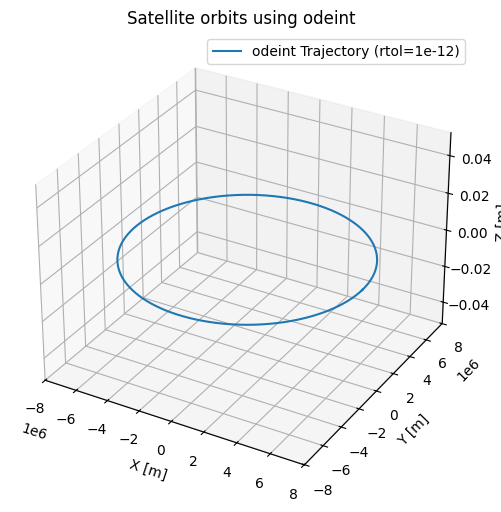

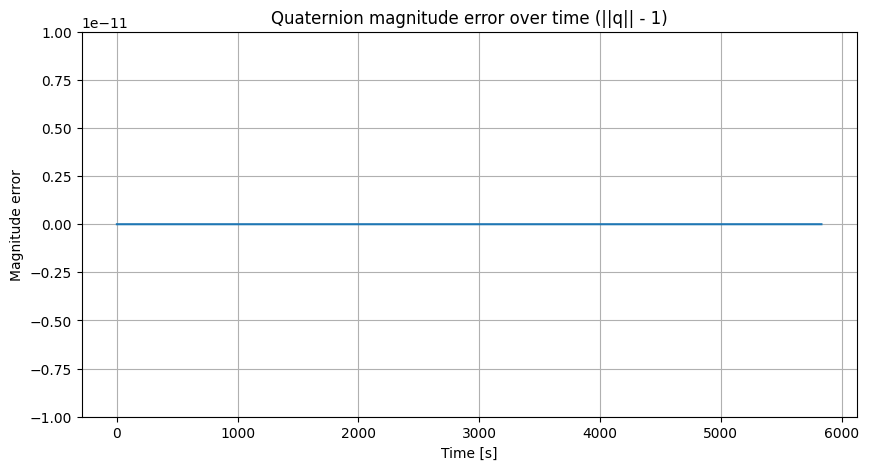

허용오차 실험 결과(수치적 접근)

허용오차: Loose (느슨함) (rtol=1.0e-04, atol=1.0e-04)
 - 최종 위치 오차: 72764.3260 m
 - 함수 호출 횟수 (nfe): 234
 - 내부 스텝 수 (nst): 86

허용오차: Default (기본값) (rtol=1.5e-08, atol=1.0e-08)
 - 최종 위치 오차: 32.9020 m
 - 함수 호출 횟수 (nfe): 525
 - 내부 스텝 수 (nst): 190

허용오차: Strict (엄격함) (rtol=1.0e-12, atol=1.0e-12)
 - 최종 위치 오차: 0.0000 m
 - 함수 호출 횟수 (nfe): 1608
 - 내부 스텝 수 (nst): 621


In [37]:
from scipy.integrate import odeint

###### your code here ######
def f(z,t):    # odeint 대입을 위한 t 설정
    r,v,q,w = z[0:3],z[3:6],z[6:10],z[10:13]
    rdot=v
    vdot=-mu/(nl.norm(r)**3)*r
    qdot=0.5*Omega(w)@q
    wdot=np.linalg.inv(J)@(-np.cross(w, J @ w))
    return np.concatenate((rdot,vdot,qdot,wdot))

steps=int(T/dt)
t=np.linspace(0,T,steps+1)
# 공식 문서를 참고하여 rtol, atol, full_output 설정
sol_odeint,info=odeint(f,x0,t,rtol=1e-12,atol=1e-12,full_output=True)

# 3D 궤적
fig_odeint=plt.figure(figsize=(12,6))
ax = fig_odeint.add_subplot(111,projection='3d')
pos=sol_odeint[:, 0:3]
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], label='odeint Trajectory (rtol=1e-12)')
ax.set_title('Satellite orbits using odeint')
ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.set_zlabel('Z [m]')
ax.legend()
plt.show()

# 쿼터니언 크기 오차
q_norm_error=np.linalg.norm(sol_odeint[:, 6:10], axis=1)-1.0
#쿼터니언의 크기가 1이므로 1을 빼야 오차 확인 가능
plt.figure(figsize=(10, 5))
plt.plot(t, q_norm_error)
plt.title('Quaternion magnitude error over time (||q|| - 1)')
plt.xlabel('Time [s]')
plt.ylabel('Magnitude error')
plt.ylim(-10e-12,10e-12)
plt.grid(True)
plt.show()

# 허용오차(Tolerance)
tolerances = { "Loose (느슨함)": {'rtol': 1e-4, 'atol': 1e-4},
            "Default (기본값)": {'rtol': 1.49e-8, 'atol': 1e-8},
            "Strict (엄격함)": {'rtol': 1e-12, 'atol': 1e-12} }

print("허용오차 실험 결과(수치적 접근)")
for name, tol in tolerances.items():
    sol,info=odeint(f,x0,t,rtol=tol['rtol'],atol=tol['atol'],full_output=True)
    # 최종 위치 오차 계산 (엄격한 기준 해와 비교)
    pos_error=nl.norm(sol[-1, 0:3]-sol_odeint[-1, 0:3])

    print(f"\n허용오차: {name} (rtol={tol['rtol']:.1e}, atol={tol['atol']:.1e})")
    print(f" - 최종 위치 오차: {pos_error:.4f} m")
    print(f" - 함수 호출 횟수 (nfe): {info['nfe'][-1]}")
    print(f" - 내부 스텝 수 (nst): {info['nst'][-1]}")


scipy.integrate.odeint  
: 상미분방정식 초기값 문제를 풀기 위한 라이브러리로, 내부적으로는 FORTRAN 라이브러리인 LSODA를 사용하여 문제의 복잡도에 따라 자동으로 적분 방법을 전환하며 효율적인 방식으로 해를 계산할 수 있다.
이는 앞선 코드에서 odeint(func,x0,t,stiffness)와 같은 형태로 대입하였다.
- func: f(x,t)와 같이 상태 벡터 x와 시간 t를 입력받아 상태의 미분값(dx/dt)을 반환하는 함수
- x0: 시뮬레이션의 시작점인 초기 상태 벡터
- t: 해를 계산하고자 하는 시간 지점들을 담은 np.linspace

허용 오차 선택 접근 방식  
: 정확도 제어를 위해 공식 문서에서 제공하는 두 옵션을 활용하기로 하였다.
- rtol (relative tolerance): 상대 허용 오차. 상태 벡터의 각 요소에 대한 허용 오차를 상태 값의 크기에 비례하여 설정하는데, 해당 값이 작을수록 더 정확한 해를 계산한다.
- atol (absolute tolerance): 절대 허용 오차. 상태 값이 0에 가까워질 때 rtol만으로는 오차 제어가 어려워지므로, atol이 최소 오차 한계 역할을 수행할 수 있다.

솔버 진단  
: 솔버의 성능을 평가하기 위해 공식 문서에서 제공하는 full_output=True 옵션 활용하기로 하였다.  
(이 옵션은 결과 배열 외에 진단 정보가 담긴 딕셔너리를 추가로 반환하는 역할)
- nfe (Number of function evaluations): 솔버가 동역학 함수를 호출한 총 횟수. 이 값이 클수록 계산 비용이 높다.
- nst (Number of time steps): 솔버가 내부적으로 사용한 총 스텝 수. 가변 스텝 방식을 사용하므로 사용자가 지정한 시간 배열 크기와는 다르고, 이 값 또한 계산 비용을 의미한다.

결과  
: 앞선 코드를 통해 odeint를 활용하여 위성의 궤도를 3D 플롯으로 확인할 수 있다. 이에 따라 쿼터니언 크기 오차를 시각화 해보니 오차가 10e-12 scale에서도 매우 작게 유지됨을 확인할 수 있었다.  
  
또한, 허용 오차 조건을 3가지로 나누어 최종 위치 오차, 함수 호출 횟수, 내부 스텝 수에 대하여 분류하여 비교하여 수치적으로 접근할 수 있었다. 이를 통해 정확도를 높이면(즉, 허용 오차를 낮추면) 함수 호출 횟수와 내부 스텝 수 자체가 증가함을 확인할 수 있었다.(정확도와 솔버 자체의 계산량은 비례, 이는 효율성에 관한 논의)  
  
결과적으론 어떤 옵션이 중요한지는 해석해야 하는 상황에 따라 결정됨을 알게 되었다. 만약 실시간 시뮬레이션 제어과 같은 작업을 해야 하는 경우에는 계산 속도가 중요시되니 허용 오차를 비교적 느슨하게 설정할 필요가 있지만, 정밀한 분석을 해야하는 작업에선 엄격한 허용 오차를 셋업하여 결과의 신뢰도를 높일 필요가 있다.
  
*reference : https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html